In [1]:
# importing google drive or mounting
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/drive/MyDrive/supply_chain_analytics/data/supply_chain_data.csv')

In [4]:
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [5]:
"""The Information i claimed to be the part is (
  Sales (prices, quantities sold, revenue)

Inventory (stock levels, availability)

Supply chain operations (lead times, shipping costs, carriers)

Quality (defect rates, inspection results)

Suppliers and locations
)"""

'The Information i claimed to be the part is (\n  Sales (prices, quantities sold, revenue)\n\nInventory (stock levels, availability)\n\nSupply chain operations (lead times, shipping costs, carriers)\n\nQuality (defect rates, inspection results)\n\nSuppliers and locations\n)'

In [6]:
df.shape

(100, 24)

In [7]:
df.isnull().sum()

,0
Product type,0
SKU,0
Price,0
Availability,0
Number of products sold,0
Revenue generated,0
Customer demographics,0
Stock levels,0
Lead times,0
Order quantities,0


In [8]:
for col in df.columns:
  if df[col].dtype == 'object':
    unique_values = df[col].nunique()
    print(f'{col}: {unique_values} unique values (categorical)')
  else:
    print(f'{col}: {df[col].dtype} ^^ range: MIN: {df[col].min():.2f} MAX: {df[col].max():.2f}')


Product type: 3 unique values (categorical)
SKU: 100 unique values (categorical)
Price: float64 ^^ range: MIN: 1.70 MAX: 99.17
Availability: int64 ^^ range: MIN: 1.00 MAX: 100.00
Number of products sold: int64 ^^ range: MIN: 8.00 MAX: 996.00
Revenue generated: float64 ^^ range: MIN: 1061.62 MAX: 9866.47
Customer demographics: 4 unique values (categorical)
Stock levels: int64 ^^ range: MIN: 0.00 MAX: 100.00
Lead times: int64 ^^ range: MIN: 1.00 MAX: 30.00
Order quantities: int64 ^^ range: MIN: 1.00 MAX: 96.00
Shipping times: int64 ^^ range: MIN: 1.00 MAX: 10.00
Shipping carriers: 3 unique values (categorical)
Shipping costs: float64 ^^ range: MIN: 1.01 MAX: 9.93
Supplier name: 5 unique values (categorical)
Location: 5 unique values (categorical)
Lead time: int64 ^^ range: MIN: 1.00 MAX: 30.00
Production volumes: int64 ^^ range: MIN: 104.00 MAX: 985.00
Manufacturing lead time: int64 ^^ range: MIN: 1.00 MAX: 30.00
Manufacturing costs: float64 ^^ range: MIN: 1.09 MAX: 99.47
Inspection resu

In [9]:
df.head(1)
print(df.describe(include='all'))

       Product type   SKU       Price  Availability  Number of products sold  \
count           100   100  100.000000    100.000000               100.000000   
unique            3   100         NaN           NaN                      NaN   
top        skincare  SKU0         NaN           NaN                      NaN   
freq             40     1         NaN           NaN                      NaN   
mean            NaN   NaN   49.462461     48.400000               460.990000   
std             NaN   NaN   31.168193     30.743317               303.780074   
min             NaN   NaN    1.699976      1.000000                 8.000000   
25%             NaN   NaN   19.597823     22.750000               184.250000   
50%             NaN   NaN   51.239831     43.500000               392.500000   
75%             NaN   NaN   77.198228     75.000000               704.250000   
max             NaN   NaN   99.171329    100.000000               996.000000   

        Revenue generated Customer demo

In [10]:
cat_col = df.select_dtypes(include='object').columns
df[cat_col].head()
df['SKU'].nunique()


100

### Feature Engineering

In [11]:
df['revenue per unit'] = (df['Revenue generated'] / df['Number of products sold'] + 1)


In [12]:
df['total lead time'] = df['Lead times'] + df['Manufacturing lead time']

In [13]:
df['sales velocity'] = np.log1p(df['Number of products sold'] / df['total lead time'])

In [14]:
df['stock availability'] = np.log1p(
    np.where(
        df['Stock levels'] == 0,
        np.nan,  # Replace inf with NaN
        (df['Number of products sold'] / df['Stock levels'] + 1)
    )
)

In [15]:
df['cost efficiency'] = df['Revenue generated'] / (df['Costs'] + df['Shipping costs'])

In [16]:
df['profit margin %'] = ((df['Revenue generated'] - df['Manufacturing costs'])
/ df['Revenue generated'] * 100)

In [17]:
df['quality score'] = 100 - df['Defect rates']

In [18]:
# from sklearn.preprocessing import LabelEncoder
# import pickle

# le = LabelEncoder()
# copy_df = df.copy()
# for col in df[cat_col]:
#   copy_df[col] = le.fit_transform(df[col])

# with open('/content/drive/MyDrive/supply_chain_analytics/preprocessors/sku_encoder.pkl', 'wb') as f:
#   pickle.dump(le, f)

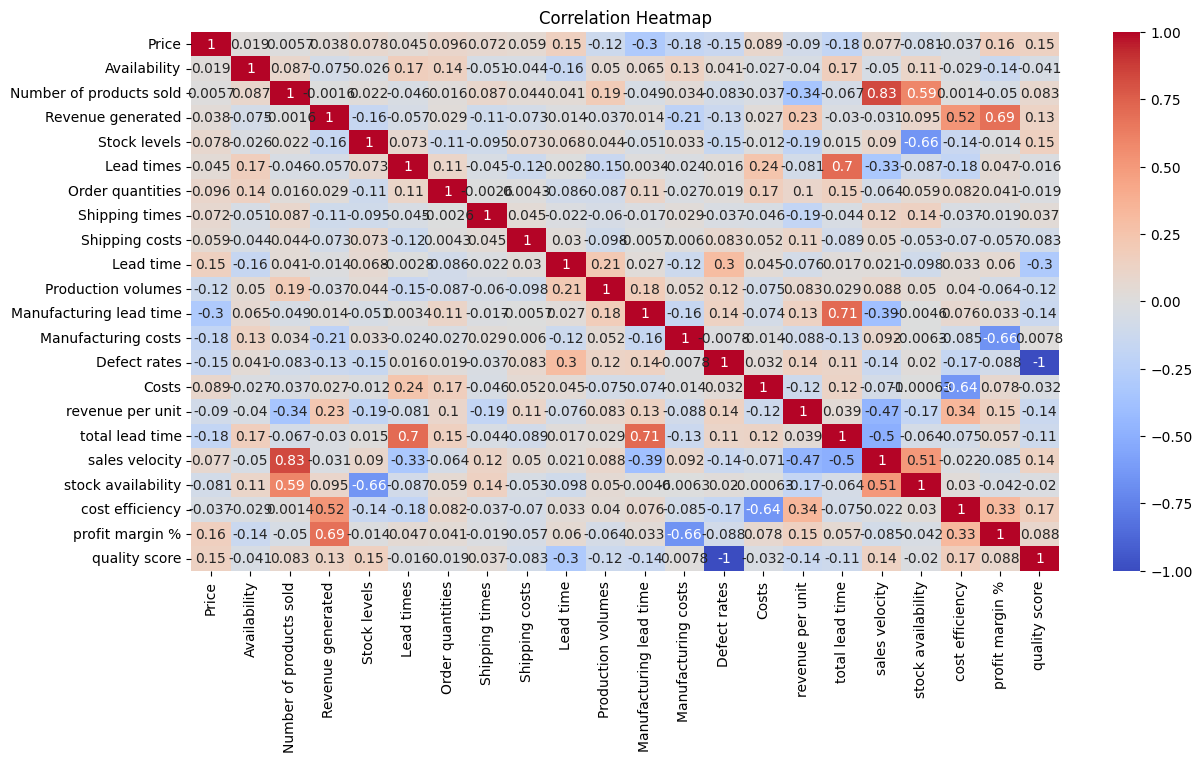

<Figure size 640x480 with 0 Axes>

In [19]:
copy_df = df.copy()
correlation = copy_df.corr(numeric_only=True)
plt.figure(figsize=(14, 7))

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
plt.savefig('corre.png')

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [21]:
# from numpy import ndarray
# def scale(train_data):
#   mean = train_data.mean(axis=0)
#   train_data -= mean

#   std = train_data.std(axis=0)

#   train_data /= std

#   return train_data.to_numpy()

# train_df = scale(copy_df)

In [22]:
copy_df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Transportation modes,Routes,Costs,revenue per unit,total lead time,sales velocity,stock availability,cost efficiency,profit margin %,quality score
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Road,Route B,187.752075,11.800495,36,3.147499,2.761754,45.420053,99.465714,99.773590
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Road,Route B,503.065579,11.137092,60,2.585255,2.765488,14.549843,99.549427,95.145932
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Air,Route C,141.920282,1198.218703,37,0.195745,2.302585,63.862410,99.679591,95.419407
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Rail,Route A,254.776159,94.576342,31,1.302211,1.724318,30.279388,99.541322,95.253351
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Air,Route A,923.440632,4.084392,6,4.984748,5.171620,2.897029,96.573051,96.854420


In [23]:
copy_df['Shipping costs']

,Shipping costs
0,2.956572
1,9.716575
2,8.054479
3,1.729569
4,3.890548
...,...
95,8.630339
96,5.352878
97,7.904846
98,1.409801


In [24]:
copy_df['Shipping costs'][0]

np.float64(2.956572139430807)

In [25]:
copy_df.columns

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs', 'revenue per unit',
       'total lead time', 'sales velocity', 'stock availability',
       'cost efficiency', 'profit margin %', 'quality score'],
      dtype='object')

In [26]:
96*802+187+2.95

77181.95

In [27]:
copy_df['SKU'].value_counts(ascending=False).index

Index(['SKU0', 'SKU1', 'SKU2', 'SKU3', 'SKU4', 'SKU5', 'SKU6', 'SKU7', 'SKU8',
       'SKU9', 'SKU10', 'SKU11', 'SKU12', 'SKU13', 'SKU14', 'SKU15', 'SKU16',
       'SKU17', 'SKU18', 'SKU19', 'SKU20', 'SKU21', 'SKU22', 'SKU23', 'SKU24',
       'SKU25', 'SKU26', 'SKU27', 'SKU28', 'SKU29', 'SKU30', 'SKU31', 'SKU32',
       'SKU33', 'SKU34', 'SKU35', 'SKU36', 'SKU37', 'SKU38', 'SKU39', 'SKU40',
       'SKU41', 'SKU42', 'SKU43', 'SKU44', 'SKU45', 'SKU46', 'SKU47', 'SKU48',
       'SKU49', 'SKU50', 'SKU51', 'SKU52', 'SKU53', 'SKU54', 'SKU55', 'SKU56',
       'SKU57', 'SKU58', 'SKU59', 'SKU60', 'SKU61', 'SKU62', 'SKU63', 'SKU64',
       'SKU65', 'SKU66', 'SKU67', 'SKU68', 'SKU69', 'SKU70', 'SKU71', 'SKU72',
       'SKU73', 'SKU74', 'SKU75', 'SKU76', 'SKU77', 'SKU78', 'SKU79', 'SKU80',
       'SKU81', 'SKU82', 'SKU83', 'SKU84', 'SKU85', 'SKU86', 'SKU87', 'SKU88',
       'SKU89', 'SKU90', 'SKU91', 'SKU92', 'SKU93', 'SKU94', 'SKU95', 'SKU96',
       'SKU97', 'SKU98', 'SKU99'],
      dtype='objec

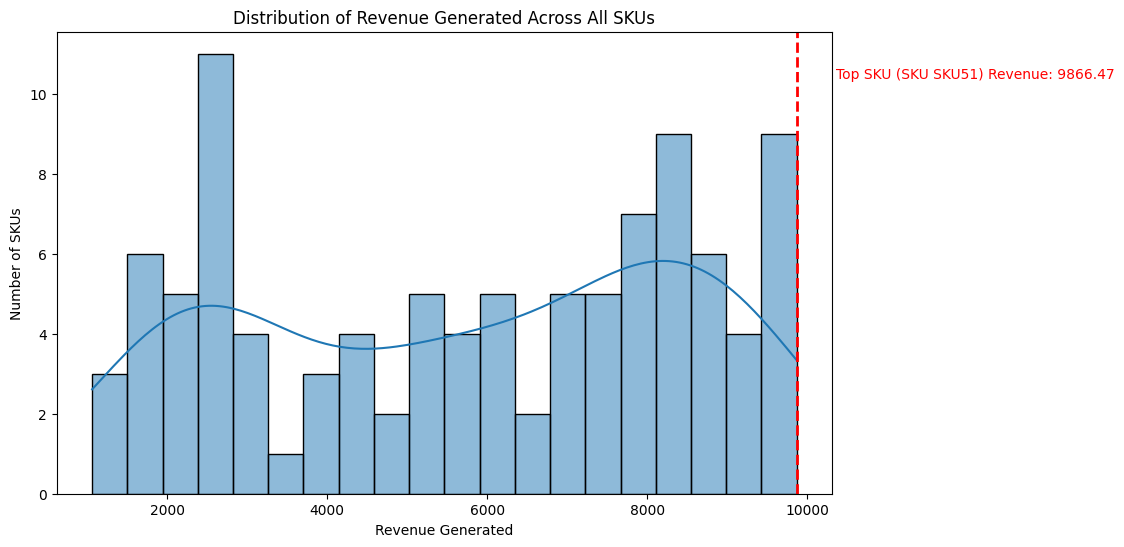

The top performing SKU (SKU SKU51) has a revenue of $9866.47


In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(copy_df['Revenue generated'], bins=20, kde=True)
plt.title('Distribution of Revenue Generated Across All SKUs')
plt.xlabel('Revenue Generated')
plt.ylabel('Number of SKUs')

top_revenue_sku_data = copy_df.loc[copy_df['Revenue generated'].idxmax()]
top_sku_index = top_revenue_sku_data['SKU']
top_sku_revenue = top_revenue_sku_data['Revenue generated']

plt.axvline(top_sku_revenue, color='red', linestyle='dashed', linewidth=2)
min_ylim, max_ylim = plt.ylim()
plt.text(top_sku_revenue*1.05, max_ylim*0.9, f'Top SKU (SKU {top_sku_index}) Revenue: {top_sku_revenue:.2f}', color='red')

plt.show()
print(f"The top performing SKU (SKU {top_sku_index}) has a revenue of ${top_sku_revenue:.2f}")

In [29]:
copy_df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Transportation modes,Routes,Costs,revenue per unit,total lead time,sales velocity,stock availability,cost efficiency,profit margin %,quality score
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Road,Route B,187.752075,11.800495,36,3.147499,2.761754,45.420053,99.465714,99.773590
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Road,Route B,503.065579,11.137092,60,2.585255,2.765488,14.549843,99.549427,95.145932
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Air,Route C,141.920282,1198.218703,37,0.195745,2.302585,63.862410,99.679591,95.419407
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Rail,Route A,254.776159,94.576342,31,1.302211,1.724318,30.279388,99.541322,95.253351
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Air,Route A,923.440632,4.084392,6,4.984748,5.171620,2.897029,96.573051,96.854420


In [30]:
sku_demographics = copy_df.groupby(['Customer demographics', 'SKU']).size().unstack(level='SKU').fillna(0)

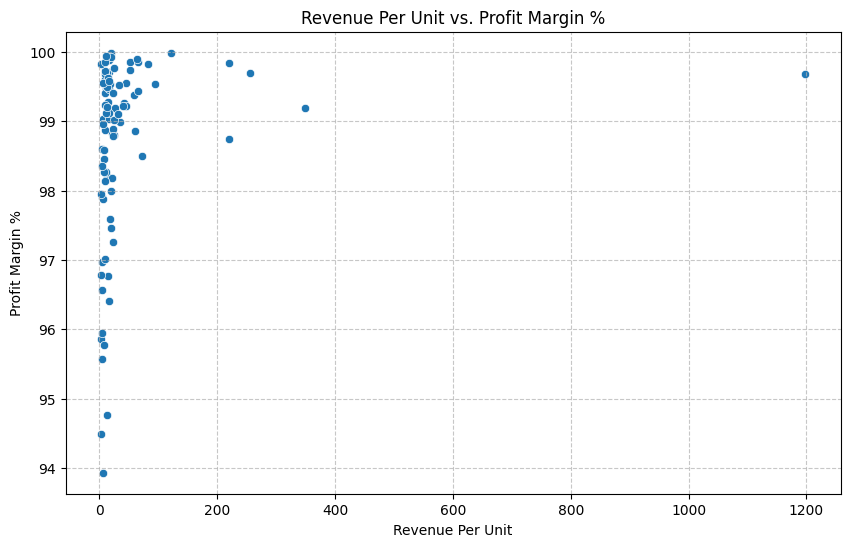

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='revenue per unit', y='profit margin %', data=copy_df)
plt.title('Revenue Per Unit vs. Profit Margin %')
plt.xlabel('Revenue Per Unit')
plt.ylabel('Profit Margin %')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

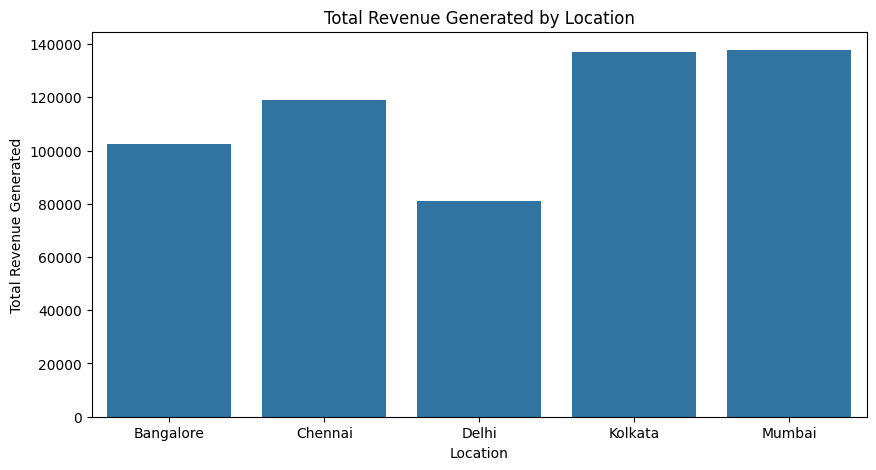

In [32]:
revenue_on_location = copy_df.groupby('Location')['Revenue generated'].sum()

plt.figure(figsize=(10, 5))
sns.barplot(x=revenue_on_location.index, y=revenue_on_location.values)
plt.title('Total Revenue Generated by Location')
plt.xlabel('Location')
plt.ylabel('Total Revenue Generated')
plt.show()

In [33]:
order_trans_mode = copy_df.groupby('Transportation modes')['Order quantities'].sum()
display(order_trans_mode)

,Order quantities
Transportation modes,
Air,1341
Rail,1342
Road,1386
Sea,853


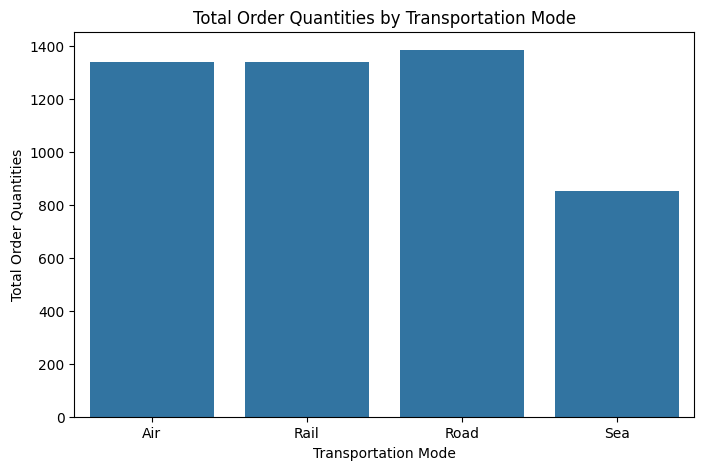

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(x=order_trans_mode.index, y=order_trans_mode.values)
plt.title('Total Order Quantities by Transportation Mode')
plt.xlabel('Transportation Mode')
plt.ylabel('Total Order Quantities')
plt.show()

<Axes: xlabel='Product type'>

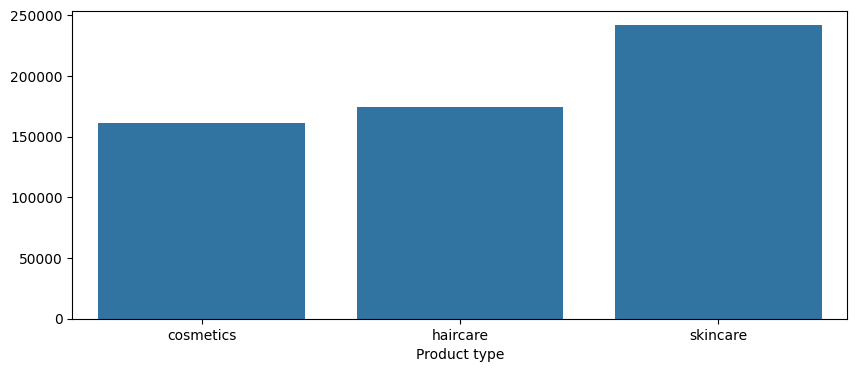

In [35]:
revnue_on_product = copy_df.groupby('Product type')['Revenue generated'].sum()



plt.figure(figsize=(10, 4))
sns.barplot(x=revnue_on_product.index, y=revnue_on_product.values)

In [36]:
product_demog_margin = copy_df.groupby(['Product type', 'Customer demographics'])['profit margin %'].mean().unstack()
product_demog_margin

Customer demographics,Female,Male,Non-binary,Unknown
Product type,,,,
cosmetics,99.227371,98.412247,99.389534,99.336446
haircare,99.212835,98.794812,98.593850,98.330825
skincare,98.866003,99.363067,98.026835,98.598755


In [37]:
import plotly.express as px

# Prepare data for plotting from the product_demog_margin DataFrame
plot_data = product_demog_margin.reset_index().melt(id_vars='Product type', var_name='Customer Demographics', value_name='Profit Margin %')

fig = px.bar(
    plot_data,
    x='Product type',
    y='Profit Margin %',
    color='Customer Demographics',
    barmode='group',
    title='Interactive: Average Profit Margin % by Product Type and Customer Demographics',
    labels={'Profit Margin %': 'Average Profit Margin (%)'},
    color_discrete_sequence=px.colors.qualitative.D3 # Changed to a qualitative palette
)

# You can also set a specific y-axis range to highlight the small differences
# For example, to zoom in on the 97.5-100% range:
# fig.update_yaxes(range=[97.5, 100])

fig.show()

In [38]:
copy_df.head(2)

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Transportation modes,Routes,Costs,revenue per unit,total lead time,sales velocity,stock availability,cost efficiency,profit margin %,quality score
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Road,Route B,187.752075,11.800495,36,3.147499,2.761754,45.420053,99.465714,99.773590
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Road,Route B,503.065579,11.137092,60,2.585255,2.765488,14.549843,99.549427,95.145932


In [39]:
revenue_quantity = copy_df.groupby('Product type')['Number of products sold'].sum()

import plotly.express as px

fig = px.bar(
    x=revenue_quantity.index,
    y=revenue_quantity.values,
    labels={'x': 'Product Type', 'y': 'Total Revenue'},
    title='Total Revenue Generated by Product Type',
    color=revenue_quantity.index,
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.show()

In [40]:
copy_df.head(1)

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Transportation modes,Routes,Costs,revenue per unit,total lead time,sales velocity,stock availability,cost efficiency,profit margin %,quality score
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Road,Route B,187.752075,11.800495,36,3.147499,2.761754,45.420053,99.465714,99.77359


In [41]:
copy_df['Routes'].nunique()

3

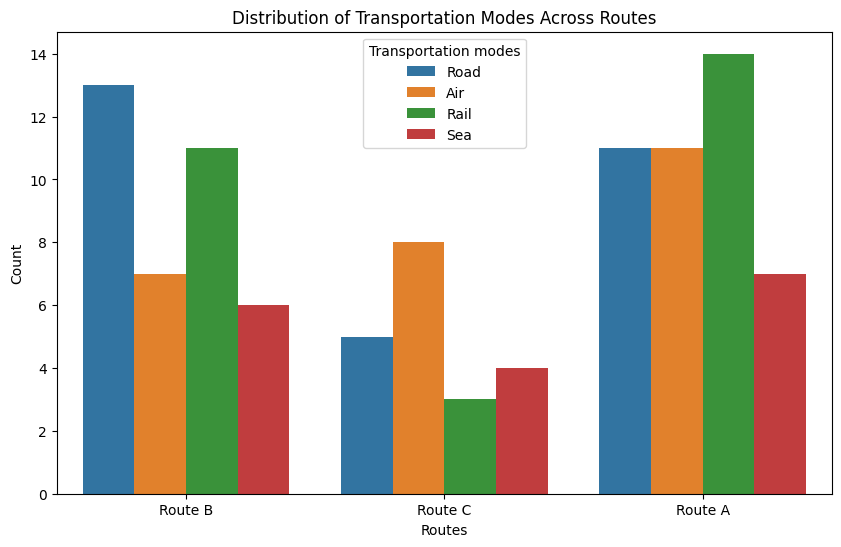

In [42]:
routes_trans = copy_df[['Routes', 'Transportation modes']]

plt.figure(figsize=(10, 6))
sns.countplot(x='Routes', hue='Transportation modes', data=routes_trans)
plt.title('Distribution of Transportation Modes Across Routes')
plt.xlabel('Routes')
plt.ylabel('Count')
plt.show()

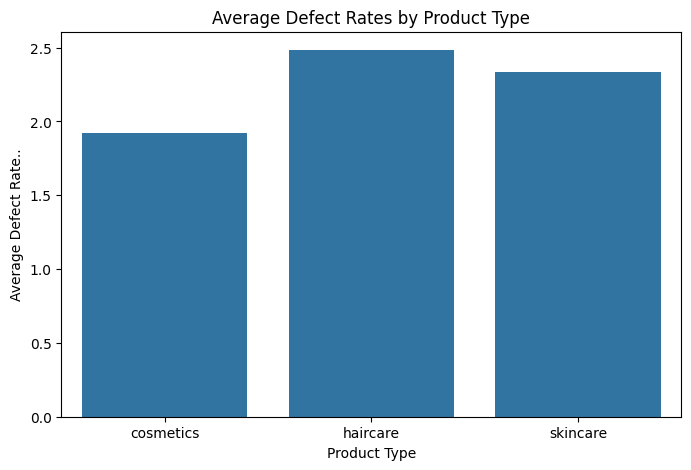

In [43]:
avg_defect_rate_by_product = copy_df.groupby('Product type')['Defect rates'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Product type', y='Defect rates', data=avg_defect_rate_by_product)
plt.title('Average Defect Rates by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Average Defect Rate..')
plt.show()

# Problem Definition & Data Preparation

Target: Revenue generated (Continuous)
Features: All other columns apart from ‘SKU’ (which is our identifier) and engineered features that we may wish to exclude for leakage.
We'll use the copy_df created in the notebook. For example, revenue per unit is directly related to revenue generated; hence, it should be excluded for leakage. Also, profit margin% is dependent on revenue; hence, it should be excluded.

Preparing the Data

In [44]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer   # not needed as no missing values, but kept for safety

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib

In [45]:
# copy_df already contains engineered features
# We'll work on a fresh copy to avoid altering the original
df_model = copy_df.copy()

# Define target
target = 'Revenue generated'

# Drop columns that would cause leakage or are identifiers
# Exclude 'target' from this list, as it's what we want to predict.
leakage_or_id_cols = [
    'SKU',
    'revenue per unit',
    'profit margin %',
    'cost efficiency',
    'sales velocity', # Removing engineered feature
    'stock availability' # Removing engineered feature
    ]

# Drop these columns from df_model to prepare the feature set, keeping the target for now.
df_model.drop(columns=leakage_or_id_cols, inplace=True, errors='ignore')

In [46]:
# Now, separate features (X) and target (y)
y = df_model[target]
X = df_model.drop(columns=[target])

In [47]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Product type', 'Customer demographics', 'Shipping carriers', 'Supplier name', 'Location', 'Inspection results', 'Transportation modes', 'Routes']
Numerical columns: ['Price', 'Availability', 'Number of products sold', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping costs', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Defect rates', 'Costs', 'total lead time', 'quality score']


In [48]:
from sklearn.preprocessing import FunctionTransformer

# Function to replace infinite values with NaN
def replace_inf_with_nan(X):
    X = X.copy() # Ensure we don't modify original dataframe outside the pipeline
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    return X

numeric_transformer = Pipeline(steps=[
    ('handle_inf', FunctionTransformer(replace_inf_with_nan, validate=False)), # Convert inf to nan
    ('imputer', SimpleImputer(strategy='mean')), # Impute nan values
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (80, 24), Test size: (20, 24)


In [50]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'SVR': SVR(),
    'MLP': MLPRegressor(random_state=42, max_iter=900)
}

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return r2, mae, rmse

In [51]:
results = []
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', model)])
    r2, mae, rmse = evaluate_model(pipe, X_train, y_train, X_test, y_test)
    results.append({'Model': name, 'R2': r2, 'MAE': mae, 'RMSE': rmse})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(results_df)

               Model        R2          MAE         RMSE
5                SVR -0.031254  2640.921290  2878.764379
2      Random Forest -0.125703  2656.666476  3007.705090
4            XGBoost -0.437638  2983.661372  3398.975726
3  Gradient Boosting -0.473769  2894.854357  3441.422338
1              Ridge -1.098320  3598.364225  4106.380424
0  Linear Regression -1.278975  3802.826174  4279.500998
6                MLP -2.531116  4493.684856  5326.958404


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (900) reached and the optimization hasn't converged yet.



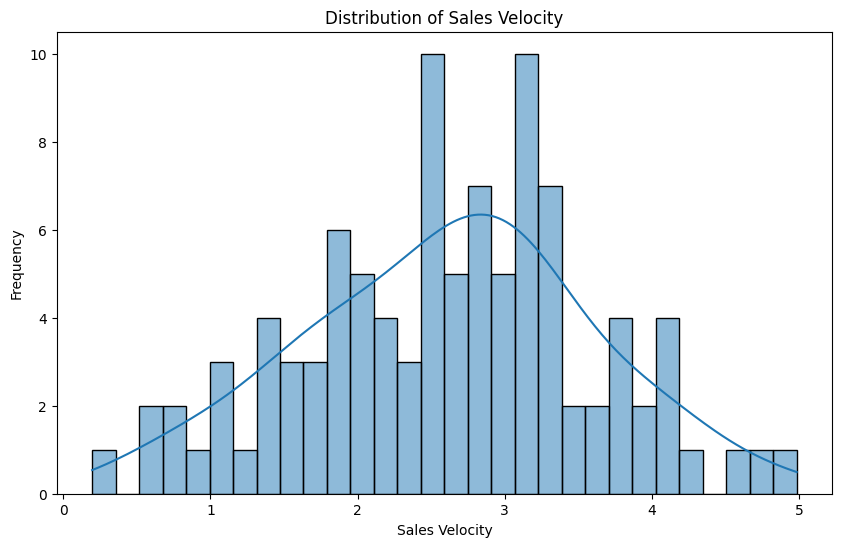

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(df['sales velocity'].dropna(), bins=30, kde=True)
plt.title('Distribution of Sales Velocity')
plt.xlabel('Sales Velocity')
plt.ylabel('Frequency')
plt.show()

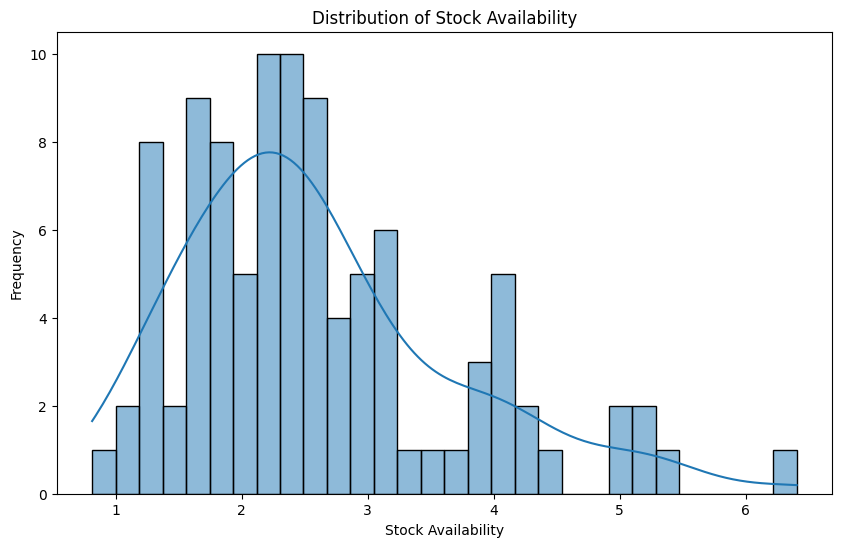

In [53]:
plt.figure(figsize=(10, 6))
sns.histplot(df['stock availability'].dropna(), bins=30, kde=True)
plt.title('Distribution of Stock Availability')
plt.xlabel('Stock Availability')
plt.ylabel('Frequency')
plt.show()

In [54]:
print('\nPerforming Cross-Validation for Models:')
cv_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', model)])

    r2_scores = cross_val_score(pipe, X, y, cv=5, scoring='r2', n_jobs=-1)
    mae_scores = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    rmse_scores = cross_val_score(pipe, X, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

    cv_results.append({
        'Model': name,
        'CV_R2_Mean': r2_scores.mean(),
        'CV_R2_Std': r2_scores.std(),
        'CV_MAE_Mean': -mae_scores.mean(), # Negate to get positive MAE
        'CV_MAE_Std': mae_scores.std(),
        'CV_RMSE_Mean': -rmse_scores.mean(), # Negate to get positive RMSE
        'CV_RMSE_Std': rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values('CV_R2_Mean', ascending=False)
print(cv_results_df)


Performing Cross-Validation for Models:
               Model  CV_R2_Mean  CV_R2_Std  CV_MAE_Mean  CV_MAE_Std  \
5                SVR   -0.031555   0.041854  2434.835407  179.870907   
2      Random Forest   -0.199602   0.095100  2586.404982  236.911923   
3  Gradient Boosting   -0.613439   0.214608  2925.054380  285.565505   
4            XGBoost   -0.767714   0.173943  3070.540177  388.238958   
1              Ridge   -0.810299   0.283352  3088.140181  171.760811   
0  Linear Regression   -0.951788   0.379719  3209.466470  255.927645   
6                MLP   -3.114686   0.216641  4749.928858  176.999664   

   CV_RMSE_Mean  CV_RMSE_Std  
5   2745.684066   130.701219  
2   2961.805278   211.743472  
3   3426.093744   253.809284  
4   3593.848638   276.495404  
1   3623.869255   269.495164  
0   3755.379165   328.033821  
6   5480.041901   216.254410  


In [55]:
param_grid_rf = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_features': [0.6, 0.8, 1.0],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(Pipeline(steps=[('preprocessor', preprocessor),
                                                ('regressor', RandomForestRegressor(random_state=42))]),
                              param_grid_rf, cv=3, scoring='r2', n_jobs=-1, verbose=1)

grid_search_rf.fit(X_train, y_train)

print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best R2 score for Random Forest:", grid_search_rf.best_score_)


Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best parameters for Random Forest: {'regressor__max_depth': None, 'regressor__max_features': 0.6, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 300}
Best R2 score for Random Forest: -0.1311890954998718


In [56]:
param_grid_svr = {
    'regressor__C': [0.1, 1, 10, 100],
    'regressor__epsilon': [0.1, 0.01, 0.001],
    'regressor__kernel': ['rbf', 'linear']
}

grid_search_svr = GridSearchCV(Pipeline(steps=[('preprocessor', preprocessor),
                                               ('regressor', SVR())]),
                             param_grid_svr, cv=3, scoring='r2', n_jobs=-1, verbose=1)

grid_search_svr.fit(X_train, y_train)

print("Best parameters for SVR:", grid_search_svr.best_params_)
print("Best R2 score for SVR:", grid_search_svr.best_score_)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters for SVR: {'regressor__C': 0.1, 'regressor__epsilon': 0.1, 'regressor__kernel': 'rbf'}
Best R2 score for SVR: -0.012230357366990482
